# RigolWFM Quick Start

**Scott Prahl**

**Apr 2026**

This notebook shows the shortest useful path through `RigolWFM`: load a waveform, inspect what was parsed, work with the sample arrays, and plot the result.

## Install

```bash
pip install RigolWFM
```

Most of the time you can let the library auto-detect the waveform family.
Pass `model=` only when you want to override detection or when you already know the scope family.

In [1]:
%config InlineBackend.figure_format = 'retina'

import os
import tempfile

os.environ.setdefault('MPLCONFIGDIR', tempfile.mkdtemp())

import matplotlib.pyplot as plt

from RigolWFM import Wfm

repo = 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/'

def sample_url(relative_path: str) -> str:
    return repo + relative_path

## 1. Load a Sample Waveform

The docs notebooks always use real sample files from the GitHub repo.
Here we load a two-channel DS1102E capture directly from a raw GitHub URL.

In [2]:
w = Wfm.from_url(sample_url('wfm/DS1102E-D.wfm'))
w

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1102E-D.wfm'


## 2. See What Was Parsed

A quick summary is usually enough to confirm that the right file, parser, and channels were found.
Use `w.describe()` when you want the full scope settings and channel metadata dump.

In [3]:
print('Scope reported by file header :', w.header_name)
print('Parser used                 :', w.parser_name)
print('Enabled analog channels     :', [ch.name for ch in w.channels])
print('Points in first channel     :', len(w.channels[0].volts))

Scope reported by file header : DS1000E
Parser used                 : wfm1000e
Enabled analog channels     : ['CH 1', 'CH 2']
Points in first channel     : 8192


In [4]:
print(w.describe())

    General:
        File Model   = DS1000E
        User Model   = auto
        Parser Model = wfm1000e
        Firmware     = unknown
        Filename     = DS1102E-D.wfm
        Channels     = [1, 2]

    Trigger:
        Mode     = edge
        Source   = CH1
        Level    = 1.60  V
        Sweep    = AUTO
        Coupling = DC
        Derived Level     = -1.20  V

     Channel 1:
         Coupling =  unknown
            Scale =     2.00  V/div
           Offset =     2.40  V
            Probe =       1X
         Inverted =    False

        Time Base =  100.000 µs/div
           Offset =    0.000  s
            Delta =  400.000 ns/point
           Points =     8192

         Count    = [        1,        2,        3  ...      8191,     8192]
           Raw    = [       41,       41,       41  ...       110,      110]
           Times  = [-1.638 ms,-1.638 ms,-1.638 ms  ...  1.638 ms, 1.638 ms]
           Volts  = [  4.32  V,  4.32  V,  4.32  V  ...  -1.20  V, -1.20  V]

     Chan

## 3. Work With the Sample Arrays

Each enabled analog channel is available as a `Channel` object in `w.channels`.
The main arrays you will usually use are `times`, `volts`, and `raw`.

In [5]:
ch1 = w.channels[0]

print('Channel name:', ch1.name)
print('First five times (s):', ch1.times[:5])
print('First five volts (V):', ch1.volts[:5])
print('First five raw ADC counts:', ch1.raw[:5])

Channel name: CH 1
First five times (s): [-0.0016384 -0.001638  -0.0016376 -0.0016372 -0.0016368]
First five volts (V): [4.32 4.32 4.32 4.32 4.32]
First five raw ADC counts: [41 41 41 41 41]


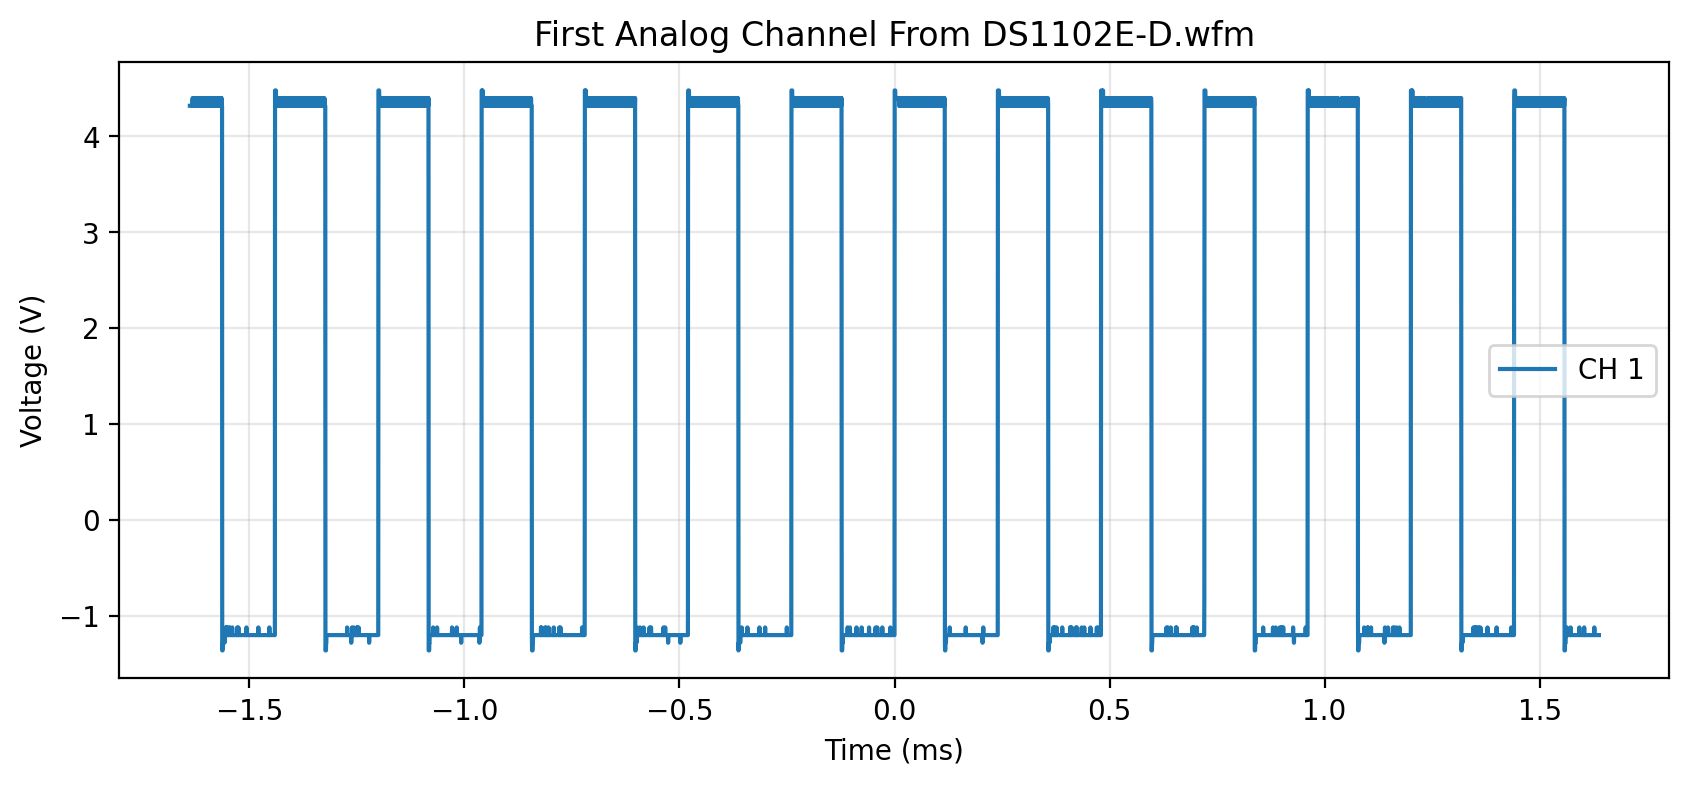

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ch1.times * 1e3, ch1.volts, label=ch1.name)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Voltage (V)')
ax.set_title('First Analog Channel From DS1102E-D.wfm')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 4. Quick Text Export Preview

`Wfm.csv()` returns a CSV-formatted string.
The dedicated export notebooks go deeper, but a quick preview is handy when you just want to confirm the X axis and channel columns.

In [7]:
rows = w.csv().splitlines()
for row in rows[:4]:
    print(row)

X,CH 1,CH 2,Start,Increment
µs, V, V,-1638.3999999999999,0.39999999999999997
-1638.3999999999999,4.32,0.00
-1637.9999999999998,4.32,0.00


## 5. Digital Channels Are Exposed Separately

If a waveform file contains parsed logic data, those traces appear in `logic_channels`.
Here is the simplest Z-series example in the repo, which exposes `D6`.

In [8]:
logic = Wfm.from_url(sample_url('wfm/DS1074Z-C.wfm'), model='Z')
sorted(logic.logic_channels)

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DS1074Z-C.wfm'


['D6']

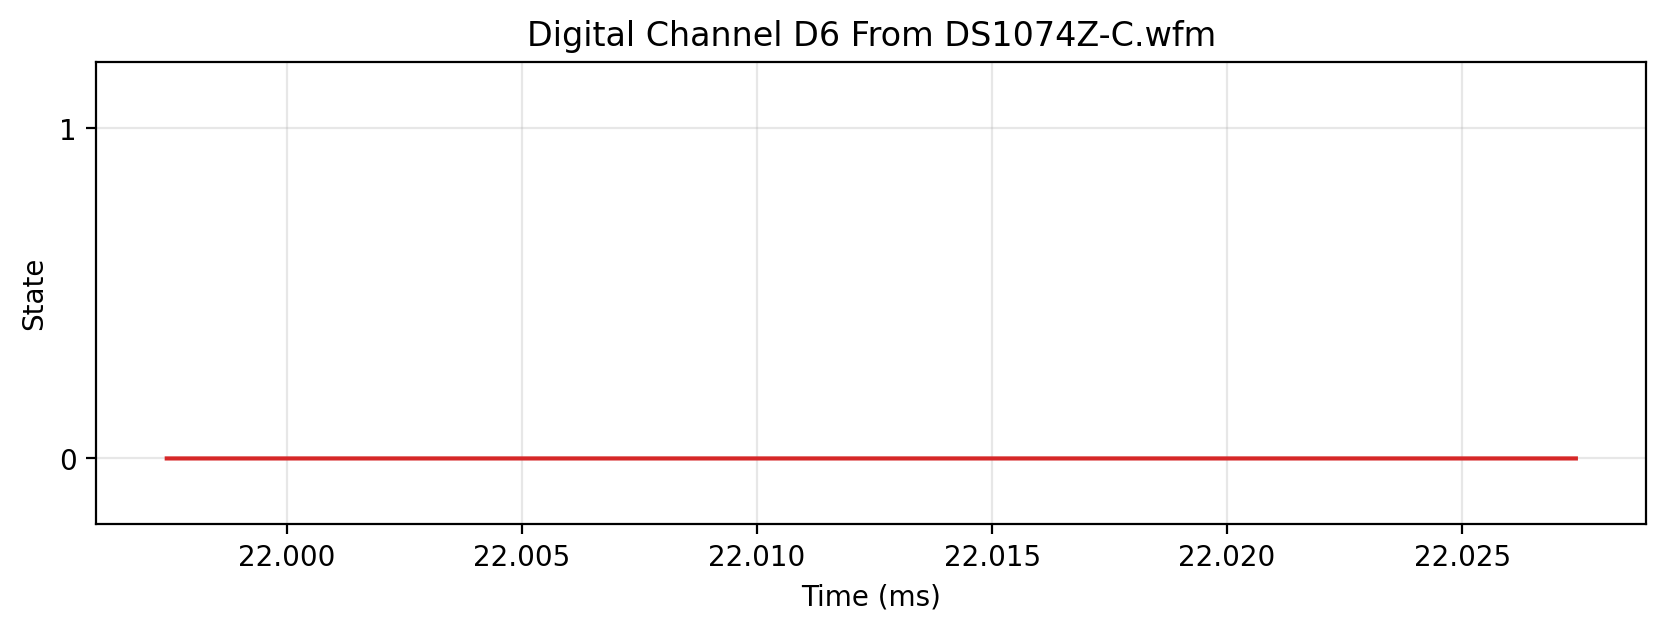

In [9]:
d6 = logic.logic_channels['D6']
t = logic.logic_times

fig, ax = plt.subplots(figsize=(10, 3))
ax.step(t[:1500] * 1e3, d6[:1500], where='post', color='tab:red')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('State')
ax.set_yticks([0, 1])
ax.set_ylim(-0.2, 1.2)
ax.set_title('Digital Channel D6 From DS1074Z-C.wfm')
ax.grid(True, alpha=0.3)
plt.show()

## 6. Local Files and Channel Selection

When you already have a waveform on disk, use `Wfm.from_file(...)`:

```python
from RigolWFM import Wfm

w = Wfm.from_file('/path/to/capture.wfm')
ch1_only = Wfm.from_file('/path/to/capture.wfm', selected='1')
```

The `selected` string filters analog channels `1` through `4` before plotting or export.

## Where To Go Next

* [Exporting Waveforms as WAV Files](Exporting-WAV.ipynb)
* [Exporting Waveforms as NPZ Files](Exporting-NPZ.ipynb)
* [Exporting Waveforms as MATLAB MAT Files](Exporting-MAT.ipynb)
* [Exporting Waveforms as Sigrok SR Files](Exporting-Sigrok-SR.ipynb)
* the family notebooks such as [DS1000E Waveforms](Rigol-DS1000E.ipynb) when you want model-specific examples